# Notatki

In [1]:
import cupy as cp

# Import wymaganych pakietów

In [2]:
import wurtzite as wzt
import numpy as np
import matplotlib.pyplot as plt
from utils_1st import displace_love2
import scipy.integrate
import dataclasses
import copy
from scipy.integrate import quad_vec
import sys

# Stałe

In [3]:
NU = 0.35
BETA_ONES = cp.eye(3)  # Jedynka 3x3
DIMS = 3  # Liczba wymiarow (x, y, z)
DIS_TOLERANCE = 1e-1
N_GLIDE_PLANE_POINTS = 10000

# Funkcje

### Funkcje pomocnicze

Poniższa funkcja tworzy sekwencję macierzy jedynek $\mathbf{1}$.

In [4]:
def broadcast_eye(n, nrepeats):
    return cp.array([cp.eye(n)]*nrepeats)

Poniższa funkcja przekształca wektor burgersa $(b_x, b_y, b_z)$ na składową krawędziową $b_e$ oraz śrubową $b_z$.

In [5]:
def get_be_bz(cell, burgers_vector):
    if isinstance(burgers_vector, cp.ndarray):
        burgers_vector = burgers_vector.get()
    burgers_vector = np.asarray(burgers_vector)
    bv_angstrom = cell.to_cartesian_indices(burgers_vector)
    be = np.sqrt(bv_angstrom[0] ** 2 + bv_angstrom[1] ** 2)
    bz = bv_angstrom[2]
    return be, bz

Oblicza całkę z funkcji `func` ($R^n \rightarrow R^m$). Całka liczona jest po linii prostej między `a` i `b` (`= limits`).

Poniższa klasa pomocnicza zbiera wszystkie informacje na temat dyslokacji w konfiguracji, t.j. ich stan (położenie, wektor burgersa) oraz ostatnią macierz obrotu.

Niezbędne do poprawnego wyznaczenia bet.

In [6]:
@dataclasses.dataclass
class DislocationsState:
    d1: wzt.model.DislocationDef
    d2: wzt.model.DislocationDef
    d1_rt: cp.ndarray
    d2_rt: cp.ndarray

    @property
    def tuple(self):
        return self.d1, self.d2, self.d1_rt, self.d2_rt

    def copy(self, **kwargs):
        return DislocationsState(**{**self.__dict__, **kwargs})

### Obroty

Poniższa funkcja tensor obrotu sztywnego na podstawie wskaźników Millera.

In [7]:
def get_rigid_rotation_tensor_miller(burgers_vector, plane, cell: wzt.model.UnitCellDef):
    normalize = wzt.dislocations._normalize
    s = cell.to_cartesian_indices(burgers_vector.get())
    s = normalize(s)
    m = np.transpose(cell.miller_to_cartesian).dot(plane.get())
    m = normalize(m)
    mxs = normalize(np.cross(m, s))
    mxsxm = normalize(np.cross(mxs, m))
    return cp.array([
        [mxsxm[0], mxsxm[1], mxsxm[2]],
        [mxs[0],   mxs[1],   mxs[2]  ],
        [m[0],     m[1],     m[2]    ],
    ])

In [8]:
class MillerIndices:

    def __init__(self, crystal, d2_global):
        cell = crystal.cell
        position = cp.asarray(d2_global.position)
        burgers_vector = cp.asarray(d2_global.b)
        plane = cp.asarray(d2_global.plane)
        position = position.reshape(-1, 1)
        self.rt = get_rigid_rotation_tensor_miller(
            burgers_vector=burgers_vector,
            plane=plane,
            cell=cell
        )
        self.rt_inv = cp.transpose(self.rt)
        self.cd = self.rt.dot(position).squeeze()  # (3, )
        
    def preprocess(self, x):
        x = self.rt.dot(x.T).T
        x = x - self.cd.reshape(1, -1)
        return x

    def postprocess(self, u):
        return self.rt_inv.dot(u.T).T

    def postprocess_points(self, x):
        x = x + self.cd.reshape(1, -1)
        return self.rt_inv.dot(x.T).T

Poniższa funkcja zwraca macierz obrotu dla punktu `p` wynikającą z dyslokacji `dis_a`. 

Zakładamy, że punkt `p` jest wyrażony we współrzędnych kartezjańskich w układzie współrzędnych zaczepionym w dyslokacji `dis_a`. Położenie dyslokacji `dis_a` może być zarówno wyrażona w układzie globalnym jak i lokalnym (`dis_a.position` nie ma znaczenia).



In [9]:
def get_rotation_matrix(l0, dis_a, p, debug=False):
    be, bz = get_be_bz(l0.cell, dis_a.b)
    dis_b_local_pos = cp.asarray(p).reshape(1, -1)
    BETA_ONES = cp.eye(3)
    betas = beta(dis_b_local_pos, be=be, bz=bz)
    F_inv = (BETA_ONES - betas)
    F = cp.linalg.inv(F_inv[0, :2, :2])

    ba = cp.asarray([1.0, 0.0])

    ba_rotated = F.dot(ba)
    ba = ba_rotated / cp.linalg.norm(ba_rotated)
    ba_orto = cp.array([[0, -1],
                        [1, 0]]).dot(ba)
    ba_z = cp.asarray([0, 0, 1])
    
    rotmatrix = cp.eye(3)
    rotmatrix[:2, 0] = ba
    rotmatrix[:2, 1] = ba_orto
    return rotmatrix

Poniższa funkcja zwraca obrócony wektor burgersa `bv` dyslokacji położonej w punkcie `p`. Wektor burgersa jest obrócony zgodne z betami wynikającymi z dysloakcji `dis_a`. 

Funkcja ta zachowuje oryginalną długość wektora burgersa `bv`.

**UWAGA: skladowa srubowa jest zerowana** (nie ma znaczenia dla eksperymentów w tym notatniku).

De facto, zwracana jest para: nowy wektor burgersa, macierz obrotu.

In [10]:
def rotate_dislocation(crystal, reference_dislocation, p, bv):
    bv = cp.asarray(bv)
    dis_b_rt = get_rotation_matrix(crystal, reference_dislocation, p)
    dis_b_b = dis_b_rt[:2, :2].dot(bv[:2]).squeeze()
    orig_norm = cp.linalg.norm(bv)
    dis_b_b = dis_b_b/cp.linalg.norm(dis_b_b)*orig_norm
    dis_b_b = cp.asarray(dis_b_b.tolist() + [0])
    return dis_b_b, dis_b_rt

### Funkcja $\beta$

Oblicza funkcję $\beta$ dla wybranego punktu `x`. Zmienna `be` to składowa krawędziowa wektora burgersa, `bz` to składowa śrubowa.

In [11]:
def beta(x, be, bz):
    x = cp.asarray(x)
    if len(x.shape) == 1:
        x = x[cp.newaxis, ...]

    x1 = x[..., 0]  # (n_atoms, )
    x2 = x[..., 1]  # (n_atoms, )
    x1_2 = x1 ** 2  # (n_atoms, )
    x2_2 = x2 ** 2  # (n_atoms, )
    r2 = x1_2 + x2_2 # (n_atoms, )

    a = be / (4 * cp.pi * (1.0 - NU) * r2 * r2)
    # du / dx1
    b11 = (-1) * a * x2 * ((3.0 - 2.0 * NU) * x1_2 + (1.0 - 2.0 * NU) * x2_2)  # (natoms, )
    b21 = (-1) * a * x1 * ((1.0 - 2.0 * NU) * x1_2 + (3.0 - 2.0 * NU) * x2_2)
    b31 = (-1) * bz / (2.0 * cp.pi) * x2 / r2
    # du / dx2
    b12 = a * x1 * ((3.0 - 2.0 * NU) * x1_2 + (1.0 - 2.0 * NU) * x2_2)
    b22 = a * x2 * ((1.0 + 2.0 * NU) * x1_2 - (1.0 - 2.0 * NU) * x2_2)
    b32 = bz / (2.0 * cp.pi) * x1 / r2
    
    result = cp.repeat(BETA_ONES.copy()[cp.newaxis, ...], len(x1), axis=0)
    result[:, 0, 0] = b11
    result[:, 1, 0] = b21
    result[:, 2, 0] = b31
    result[:, 0, 1] = b12
    result[:, 1, 1] = b22
    result[:, 2, 1] = b32

    # Atoms in the center of dislocation core: just equal 1
    # (1-beta will be zero)
    core_center_atoms = r2 < 1e-15  # (natoms, )
    result[core_center_atoms, :, :] = BETA_ONES
    return result  # (natoms, 3, 3)

Poniższa funkcja zwraca bety dla podanej kolekcji punktów `points`.

Bety są odpowiednio obracane wg podanej macierzy obrotu `rotation_matrix` t.j. $\beta_n = \mathbf{R}^T_n\beta(x-x_n)\mathbf{R}_n$.

Uwaga: poniższe obliczneia są zwektoryzowane na wszystkie punkty `points`.

In [12]:
def get_betas(crystal, d, points, rotation_matrix, dis_tolerance=DIS_TOLERANCE):
    if rotation_matrix is None:
        return cp.zeros((points.shape[0], 2, 2))
        
    be, bz = get_be_bz(crystal.cell, d.b)
    # Przenieś do układu zaczepionego w dyslokacji (istotne np. dla d1). 
    points = cp.asarray(points)-cp.asarray(d.position).reshape(1, -1)
    # points = rotation_matrix.dot(points.T).T
    betas = beta(points, be=be, bz=bz)[:, :2, :2]
    rm = rotation_matrix[:2, :2].reshape(1, 2, 2)
    # KLUCZOWA INSTRUKCJA
    betas = rm.transpose((0, 2, 1)) @ betas @ rm
    return betas

Poniższa funkcja wyznacza wartość $\beta^{\Sigma}$. Obecnie uwzględnia tylko dwie dyslokacje.

In [13]:
def get_beta_sigma(crystal, d_state):
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt

    betas_1 = get_betas(crystal, d1, l.reshape(-1, 3), d1_rt)
    betas_2 = get_betas(crystal, d2, l.reshape(-1, 3), d2_rt)
    return betas_1 + betas_2

### Algorytm: wyznaczanie pola przemieszczeń

Notacja:
- `d1`, `d2`: dyslokacja pierwsza i druga
- `rt`: macierz obrotu
- `p`: punkt (atom)
- `bv`: wektor burgersa
- `_global`: obiekt o współrzędnych w układzie globalnym
- `_local`: obiekt o współrzędnych w układzie lokalnym zaczepionym w `d2`.

Uproszczenia:
- zakłada sie, że `d2` ma wektor burgersa [1, 0, 0],

**Główna procedura**

# Eksperymenty

### Konfiguracja pierwotna

Tworzymy strukturę przechowującą siatkę krystalograficzną.

In [14]:
l0 = wzt.generate.create_lattice(
    dimensions=(6, 4, 1),  # (nx, ny, nz)
    cell="B4_GaN",
)

# %matplotlib widget
# fig, ax = wzt.visualization.plot_atoms_2d(l0, xlim=(-2, 22), ylim=(0, 12), figsize=(10, 5))
# ax.set_title("Initial configuration")

### Pierwsza dyslokacja

In [15]:
d1 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    # Położenie rdzenia dyslokacji
    position=[3.890+0.0*l0.cell.dimensions[0], 4.03+0.35, 7.5],
    # Płaszczyzna
    plane=(0, 0, 1),
    # Etykieta (tylko do prezentacji)
    label="$d_1$",
    # Kolor (tylko do prezentacji)
    color="brown"
)

# Użyj metody takiej jak w pracy Cholewinskiego
# Pelna implementacja tej metody w utils_1st.
# u0 -- gotowe pole przemiesczeń
u0, all_us = displace_love2(
    crystal=l0,
    position=d1.position,
    burgers_vector=d1.b,
    plane=d1.plane,
    bv_fraction=1.0,
)


# Przesuń atomy
l1 = l0.translate(u0)
# Zaktualizuj wiązania
l1 = wzt.generate.update_bonds(l1)

# # Wyswietl nowa siatke
# %matplotlib widget
# fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# # Wyswietl teownik
# wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
# ax.set_title("Current configuration (1st dislocation)")

### Druga dyslokacja

In [16]:
def line_integral(path, vals):
    """
    Liczy przybliżoną wartość całki krzywoliniowej, gdy F(r) zwraca macierz (d,d).

    ∫ F(r) dr ≈ Σ ( (F_i + F_{i+1})/2 ) @ (p_{i+1} - p_i)

    Parameters:
    - path: (n, d) cp.ndarray – kolejne punkty ścieżki
    - F_vals: (n, d, d) cp.ndarray – wartości funkcji macierzowej w punktach ścieżki

    Returns:
    - Całkowita wartość całki krzywoliniowej: wektor (d,)
    """
    path = cp.asarray(path, dtype=cp.float64)
    vals = cp.asarray(vals, dtype=cp.float64)

    # (n-1, d)
    deltas = path[1:] - path[:-1]   # dr

    # (n-1, d, d)
    avg = 0.5 * (vals[1:] + vals[:-1])

    # (n-1, d, d) @ (n-1, d, 1) -> (n-1, d, 1)
    contribs = cp.matmul(avg, deltas[..., None])  # (n-1, d, 1)
    integral = contribs.sum(axis=0).squeeze()  # (d,)
    return integral

In [17]:
def integrated_function(crystal, position, d_state, exclude_beta = {}):
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt
    
    betas_2 = get_betas(crystal, d2, position.reshape(-1, 3), d2_rt, dis_tolerance=0.2)
    betas = cp.zeros((position.shape[0], 2, 2))

    if 1 not in exclude_beta:
        betas_1 = get_betas(crystal, d1, position.reshape(-1, 3), d1_rt, dis_tolerance=0.2) 
        betas = betas_1

    F_inv = (broadcast_eye(2, betas.shape[0]) - betas)

    det_mask = cp.isclose(cp.linalg.det(F_inv), 0)
    F_inv[det_mask, ...] = cp.eye(2)
    F = cp.linalg.inv(F_inv)
    F[det_mask, ...] = cp.zeros(2)

    result = cp.zeros((betas.shape[0], 3, 3))
    result[:, :2, :2] = cp.matmul(F, betas_2)
    return result

In [18]:
def get_line(a, b, n=10000):
    t = cp.linspace(0, 1, n)[:, None]   # (n,1)
    points = a + t * (b - a)            # (n,3)
    return points


def get_u(crystal, x_o, x_dash, d_state, debug=False, exclude_beta: set = None):
    if exclude_beta is None:
        exclude_beta = {}
    d1 = d_state.d1
    d2 = d_state.d2
    d1_rt = d_state.d1_rt
    d2_rt = d_state.d2_rt

    def f_int(l):
        return integrated_function(crystal=crystal, position=l, d_state=d_state)
        

    direction = cp.sign(x_dash.squeeze()[1] - cp.asarray(d2.position)[1])
    offset = direction*cp.asarray([0.0, 10.0, 0.0])
    x_o1 = cp.asarray(x_o).squeeze() + offset
    x_o2 = cp.asarray([x_dash.squeeze()[0], x_o1[1], x_o1[2]])

    l1 = get_line(x_o, x_o1)
    l2 = get_line(x_o1, x_o2)
    l3 = get_line(x_o2, x_dash)
    i0 = line_integral(path=l1, vals=f_int(l1))
    i1 = line_integral(path=l2, vals=f_int(l2))
    i2 = line_integral(path=l3, vals=f_int(l3))

    integral = i0+i1+i2
    u = -integral
    
    return u

In [19]:
def get_delta_u(crystal, initial_position, current_u, d_state, x_o, exclude_beta: set = {}, plane=None):
    current_position = initial_position + current_u
    current_position = current_position.reshape(1, -1)
    psi = current_u + get_u(crystal=crystal, x_o=x_o, x_dash=current_position, d_state=d_state, exclude_beta=exclude_beta).squeeze()
    psi_jac = cp.eye(3) + integrated_function(crystal=crystal, position=current_position, d_state=d_state, exclude_beta=exclude_beta).squeeze()
    # TODO singularity? anyway, we should get error if the given array is not reversible
    psi_jac_inv = cp.linalg.inv(psi_jac)
    return (-1)*cp.matmul(psi_jac_inv, psi)

Ponizsze funkcje wyznaczaja plaszczyzne poslizgu przechodząca przez wskazana pozycje.

In [ ]:
def F_glide_plane(x, y, x0, y0, nu, bx, r0):
        return y-y0+bx/(8*cp.pi*(1-nu))*((1-2*nu)*cp.log((x**2 + y**2)/r0**2)-2*y**2/(x**2 +y**2)
                                    -(1-2*nu)*cp.log((x0**2 + y0**2)/r0**2) +2*y0**2/(x0**2+y0**2))
    

def get_crystal_surface_y0(l0, dislocation, xy, x0=0, n=100000, y0lim=(-30, 30)):
    bv_angstrom = l0.cell.to_cartesian_indices(dislocation.b)
    bx = bv_angstrom[0]
    y0s = cp.linspace(y0lim[0], y0lim[1], n)
    x, y = xy
    dis_x, dis_y, _ = dislocation.position
    x -= dis_x
    y -= dis_y
    v = F_glide_plane(x=x, y=y, x0=0, y0=y0s, nu=NU, bx=bx, r0=bx)
    return y0s[cp.argmin(cp.abs(v))]


def get_crystal_surface_oxy(position=(0, 0, 0), x0=0, y0=0, nx=2000, ny=2000, xlim=(-10, 10), ylim=(-10, 10), bx=1):
    x = cp.linspace(xlim[0], xlim[1], nx)
    y = cp.linspace(ylim[0], ylim[1], ny)
    xy = cp.meshgrid(x, y, indexing="ij")

    xy = cp.stack(xy).reshape(2, -1)

    v = F_glide_plane(x=xy[0, :], y=xy[1, :], x0=x0, y0=y0, nu=NU, bx=bx, r0=bx/2)
    v = v.reshape(nx, ny)  # F(x, y)
    mask = cp.argmin(cp.abs(v), axis=1)
    ys = []
    for i in mask:
        ys.append(y[i])
    ys = cp.stack(ys)
    x += position[0]
    ys += position[1]
    return x, ys


def get_crystal_plane(l0, dis_a, position, xlim=(-20, 20), ylim=(-20, 20), nx=20000, ny=20000):
    y0 = get_crystal_surface_y0(l0, dis_a, position[:2])
    bv_angstrom = l0.cell.to_cartesian_indices(dis_a.b)
    plane_d_x, plane_d_y = get_crystal_surface_oxy(
        position=dis_a.position, x0=0.0, y0=y0, xlim=xlim, ylim=ylim, nx=nx,
        ny=ny, bx=bv_angstrom[0]
    )
    return (plane_d_x, plane_d_y), y0


def get_glide_plane(l, d1, position):
    position = cp.asarray(position)
    crystal_plane, y0 = get_crystal_plane(l, d1, position, ylim=(-20, 20), ny=10000, nx=1000)
    plane = cp.zeros((len(crystal_plane[0]), 3))  # (n plane points, 3)
    plane[:, 0] = crystal_plane[0]  # x
    plane[:, 1] = crystal_plane[1]  # y
    return plane

Iteration: 0/3
Iteration: 1/3
Iteration: 2/3
Atom: 47

<Axes: title={'center': 'Dislocation field (u), OXY'}, xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

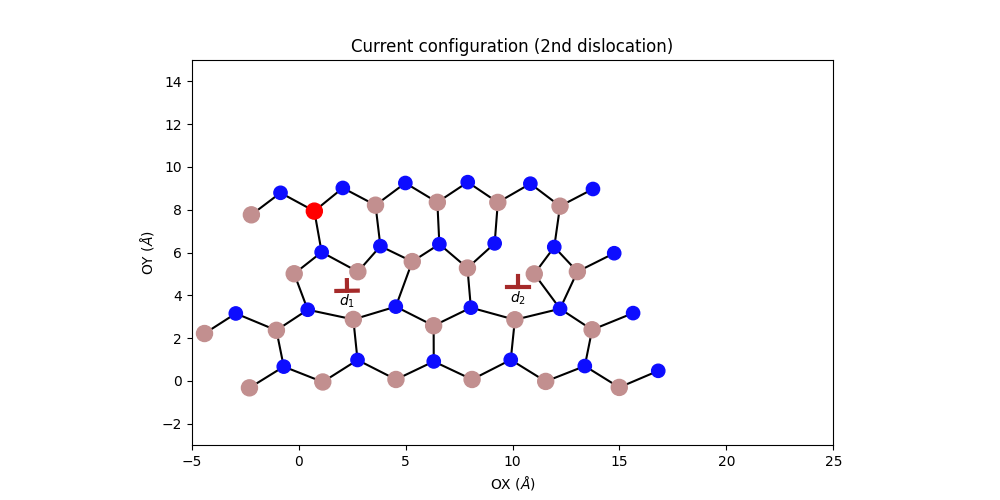

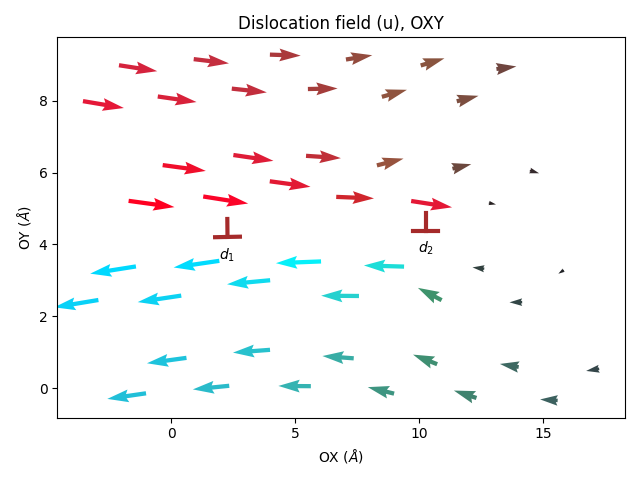

In [22]:
def displace_all(crystal, d1, d2, n_iters=3, lamb=1.0):    
    n_atoms = crystal.coordinates.shape[0]
    be, bz = get_be_bz(crystal.cell, d2.b)
    x_o = cp.asarray([0.5*be.item(), 0.0, 0.0])
    
    # Obróć dyslokację d2 zgodnie z betami wyznaczonymi przez d1.
    new_d2_bv, d2_rt = rotate_dislocation(
        crystal,
        reference_dislocation=d1,
        # przenies d2 do ukladu wspolrzednych d1
        p=cp.asarray(d2.position)-cp.asarray(d1.position),
        bv=d2.b
    )

    d2_global = dataclasses.replace(d2, b=new_d2_bv)
    d2_local = dataclasses.replace(d2_global, b=cp.asarray([1.0, 0, 0]), position=[0.0, 0, 0])

    # Wyznaczamy macierz obrotu Miller
    miller = MillerIndices(crystal=crystal, d2_global=d2_global)

    # Przenosimy wszystko do układu współrzędnych drugiej dyslokacji.
    atoms_local = miller.preprocess(cp.asarray(crystal.coordinates))  # (n atoms, 3)
    
    initial_positions = atoms_local.copy()
    
    d1_pos_local = miller.preprocess(cp.asarray(d1.position).reshape(1, 3))  # (1, 3)
    d1_local = dataclasses.replace(d1, position=d1_pos_local)

    d1_local_current = d1_local

    d_state = DislocationsState(
        d1=d1_local_current,
        d2=d2_local,
        # Zaczynamy bez obrotu d1. 
        d1_rt=cp.eye(d2_rt.shape[0]),
        d2_rt=d2_rt
    )

    current_u_d1 = cp.zeros(3)
    current_u_atoms = cp.zeros((n_atoms, 3))

    current_glide_plane_d1 = get_glide_plane(l=crystal, d1=d1_local_current, position=d2_local.position)
    current_glide_planes_atoms = []

    for i in range(n_iters):
        print(f"Iteration: {i}/{n_iters}")
        
        d1_delta_u = get_delta_u(
            crystal=crystal, 
            initial_position=d1_local.position,
            current_u=current_u_d1,
            d_state=d_state,
            x_o=x_o,
            exclude_beta={1}
        )
        current_u_d1 = current_u_d1 + d1_delta_u

        # Ustalmy obrót oraz położenie d1 w kolejnej iteracji.
        d1_bv, d1_rt = rotate_dislocation(
            crystal, 
            reference_dislocation=d2_local,
            # wektor burgersa, ktory obracamy
            bv=d1.b,
            # obecne położenie
            p=d1_local_current.position
        )
        d1_local_current = dataclasses.replace(
            d1_local_current, b=d1_bv,
            position=cp.asarray(d1_local.position)+current_u_d1
        )
        d_state = DislocationsState(
            d1=d1_local_current,
            d2=d2_local,
            d1_rt=d1_rt,
            d2_rt=d2_rt
        )
        d_state = d_state.copy(d1=d1_local_current)

        current_glide_plane_d1 = get_glide_plane(l=crystal, d1=d1_local_current, position=d2.local)

        # Determining glide planes
        current_glide_planes = []
        for c in atoms_local:
            plane = get_glide_plane(l=crystal, d1=d1_local_current, position=c)
            current_glide_planes.append(plane)
    
        for i, c in enumerate(atoms_local):
            print(f"Atom: {i}", end="\r")
            atom_delta_u = get_delta_u(
                crystal=crystal, 
                initial_position=c,
                current_u=current_u_atoms[i],
                d_state=d_state,
                x_o=x_o,
                exclude_beta={1},
                plane=current_glide_planes[i]
            )
            current_u_atoms[i] = current_u_atoms[i] + atom_delta_u

    u_atoms = cp.stack(current_u_atoms)
    
    # postprocess
    u_atoms = miller.postprocess(u_atoms).get()
    d1_local_current = dataclasses.replace(d1_local_current, b=d1_local_current.b.get())
    d1 = dataclasses.replace(d1_local_current, position=np.squeeze((cp.asarray(d1.position) + miller.postprocess(current_u_d1)).get()))
    return d1, u_atoms


d2 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    position=np.asarray(d1.position)+np.array([2.0*l0.cell.dimensions[0], 0.0, 0.0]),
    plane=(0, 0, 1),
    label="$d_2$",
    color="brown"
)

new_d1, u1 = displace_all(crystal=l1, d1=d1, d2=d2)

# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.45)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-5, 25), ylim=(-3, 15), figsize=(10, 5), highlighted_atoms={38})
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
ax.set_title("Current configuration (2nd dislocation)")
fig, ax = wzt.visualization.plot_displacement(l1, u1)
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)

<Axes: title={'center': 'Dislocation field (u), OXY'}, xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

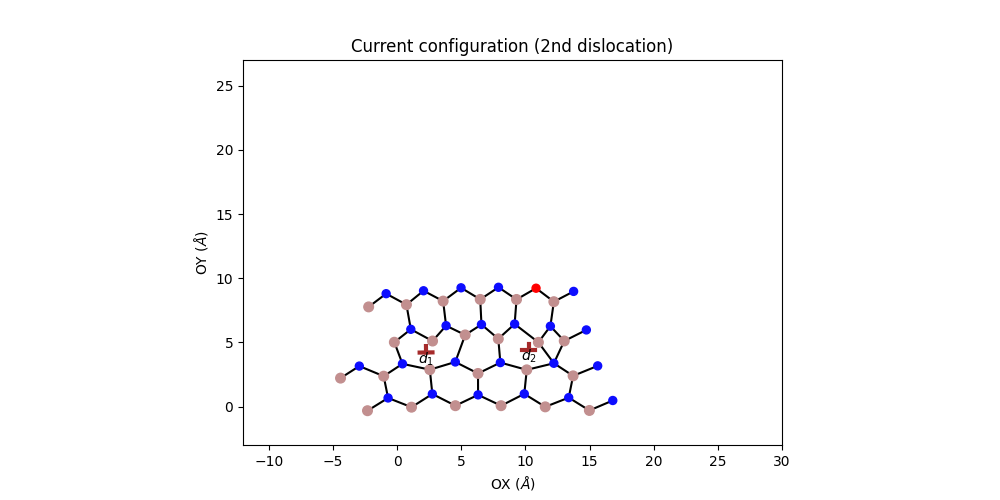

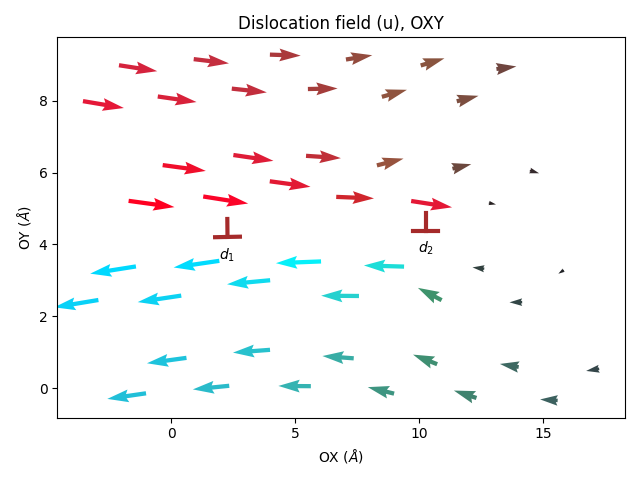

In [21]:
# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.55)

# Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-12, 30), ylim=(-3, 27), figsize=(10, 5), highlighted_atoms={45})
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
ax.set_title("Current configuration (2nd dislocation)")
fig, ax = wzt.visualization.plot_displacement(l1, u1)
wzt.visualization.display_tee_2d(ax, new_d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)